<a href="https://colab.research.google.com/github/sisi-y/100-Days-ML-Journey/blob/main/KenyaStudentData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score)
print("Done")

Done


In [2]:
np.random.seed(42)
n = 800
df = pd.DataFrame({
    'study_hours_per_day': np.random.uniform(0, 10, n),
    'attendance_pct': np.random.uniform(40, 100, n),
    'mock_exam_score': np.random.randint(20, 100, n),
    'has_textbooks': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'school_type': np.random.choice(['National', 'County', 'Private'], n),
    'distance_to_school_km': np.random.uniform(0.5, 30, n),
    'parent_education': np.random.choice(['None', 'Primary', 'Secondary', 'University'], n),
    'meals_per_day': np.random.choice([2, 2, 3], n),
})
pass_score = (
    df['study_hours_per_day'] * 4 +
    df['attendance_pct'] * 0.3 +
    df['mock_exam_score'] * 0.5 +
    df['has_textbooks'] * 10 +
    df['meals_per_day'] * 5
)
df['passed_kcse'] = (pass_score > pass_score.median()).astype(int)
print(f"Dataset: {df.shape}")
print(f"passed: {df['passed_kcse'].sum()} | Failed: {(df['passed_kcse']==0).sum()}")
print(df.head(4))


Dataset: (800, 9)
passed: 400 | Failed: 400
   study_hours_per_day  attendance_pct  mock_exam_score  has_textbooks  \
0             3.745401       82.434318               22              1   
1             9.507143       49.152343               92              1   
2             7.319939       74.577302               27              1   
3             5.986585       76.402903               89              0   

  school_type  distance_to_school_km parent_education  meals_per_day  \
0     Private              17.007576        Secondary              3   
1     Private              20.767655             None              3   
2     Private              19.913436        Secondary              3   
3      County               3.951846             None              2   

   passed_kcse  
0            0  
1            1  
2            1  
3            1  


In [3]:
le = LabelEncoder()
df['school_enc'] = le.fit_transform(df['school_type'])
df['parent_enc'] = le.fit_transform(df['parent_education'])
features = ['study_hours_per_day', 'attendance_pct', 'mock_exam_score', 'has_textbooks', 'distance_to_school_km', 'meals_per_day', 'school_enc', 'parent_enc']
X = df[features]
y = df['passed_kcse']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
print("══════════════════════════════════════")
print("  LOGISTIC REGRESSION — KCSE PREDICTOR")
print("══════════════════════════════════════")
print(f"  Accuracy:  {accuracy_score(y_test, lr_preds):.1%}")
print(f"  AUC Score: {roc_auc_score(y_test, lr_proba):.3f}")
print()
print(classification_report(y_test, lr_preds,
      target_names=['Failed', 'Passed']))

══════════════════════════════════════
  LOGISTIC REGRESSION — KCSE PREDICTOR
══════════════════════════════════════
  Accuracy:  97.5%
  AUC Score: 0.999

              precision    recall  f1-score   support

      Failed       0.95      1.00      0.98        80
      Passed       1.00      0.95      0.97        80

    accuracy                           0.97       160
   macro avg       0.98      0.97      0.97       160
weighted avg       0.98      0.97      0.97       160



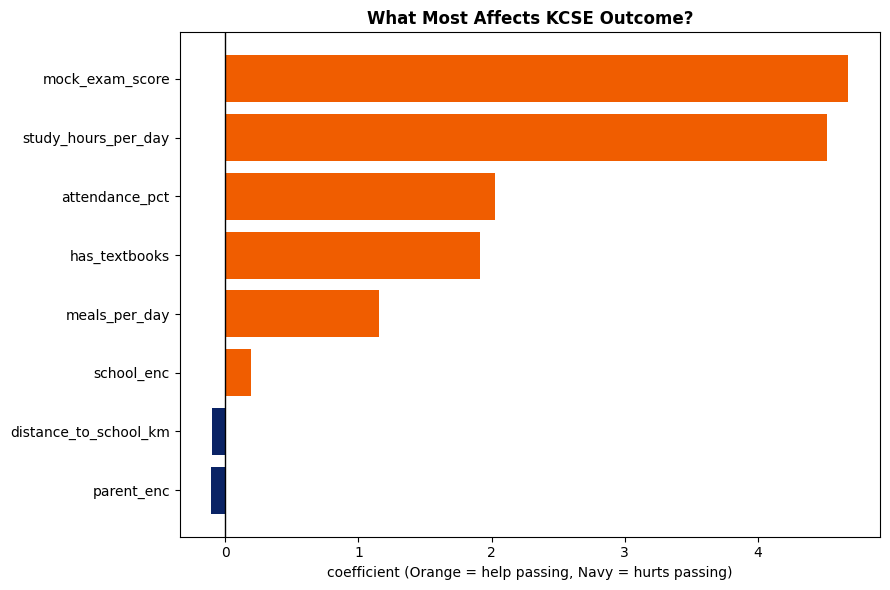


Top factors that HELP passing:
            feature  coefficient
     attendance_pct     2.023749
study_hours_per_day     4.515188
    mock_exam_score     4.676975

Top factors that HURT passing:
              feature  coefficient
           parent_enc    -0.103461
distance_to_school_km    -0.101638


In [4]:
coef_df = pd.DataFrame({
    'feature': features,
    'coefficient':lr.coef_[0]
}).sort_values('coefficient', ascending=True)
colors = ['#f05d00' if c > 0 else '#0a2365' for c in coef_df['coefficient']]
plt.figure(figsize=(9, 6))
bars = plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('coefficient (Orange = help passing, Navy = hurts passing)')
plt.title('What Most Affects KCSE Outcome?', fontweight='bold')
plt.tight_layout()

plt.show()

print("\nTop factors that HELP passing:")
print(coef_df[coef_df['coefficient']>0].tail(3).to_string(index=False))
print("\nTop factors that HURT passing:")
print(coef_df[coef_df['coefficient']<0].head(3).to_string(index=False))

In [5]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
print("KNN (K=5) Results:")
print(f"  Accuracy: {accuracy_score(y_test, knn_preds):.1%}")
print(classification_report(y_test, knn_preds, target_names=['Failed', 'Passed']))

KNN (K=5) Results:
  Accuracy: 86.9%
              precision    recall  f1-score   support

      Failed       0.86      0.89      0.87        80
      Passed       0.88      0.85      0.87        80

    accuracy                           0.87       160
   macro avg       0.87      0.87      0.87       160
weighted avg       0.87      0.87      0.87       160



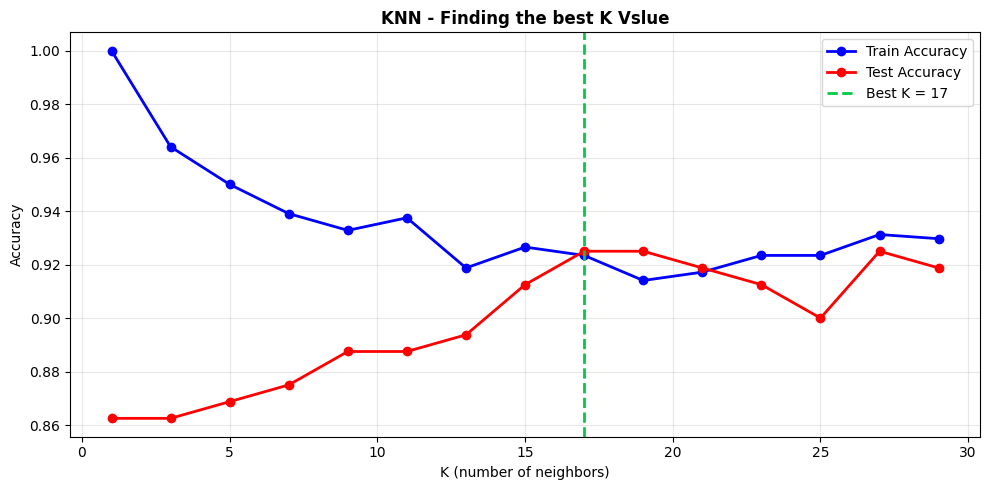


🏆 Best K = 17 with test accuracy = 92.5%


In [6]:
k_values = range(1, 31, 2)
train_accs = []
test_accs = []
for k in k_values:
  knn_k = KNeighborsClassifier(n_neighbors=k)
  knn_k.fit(X_train_scaled, y_train)
  train_accs.append(accuracy_score(y_train, knn_k.predict(X_train_scaled)))
  test_accs.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))
best_k = list(k_values)[test_accs.index(max(test_accs))]
plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accs, 'b-o', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_accs, 'r-o', label='Test Accuracy', linewidth=2)
plt.axvline(x=best_k, color='#00cb45', linestyle='--', linewidth=2,
            label=f'Best K = {best_k}')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN - Finding the best K Vslue', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n🏆 Best K = {best_k} with test accuracy = {max(test_accs):.1%}")

In [7]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
def predict_kcse(student):
  """Predict whether a student will pass KCSE."""
  school_map = {'National': 2, 'County': 0, 'Private':1}
  parent_map = {'None': 0, 'Primary': 1, 'Secondary': 2, 'University': 3}
  row = [[
      student['study_hours'], student['attendance'], student['mock_score'], student['has_textbooks'], student['distance_km'], student['meals'], school_map[student['school']], parent_map[student['parent_edu']]
  ]]
  row_scaled = scaler.transform(row)
  pred = best_knn.predict(row_scaled)[0]
  prob = best_knn.predict_proba(row_scaled)[0][1]
  result = "✅ LIKELY TO PASS KCSE" if pred == 1 else "❌ AT RISK OF FAILING"
  print(f"\nStudent: {student.get('name', 'Unknown')}")
  print(f"Prediction: {result}")
  print(f"Pass probability: {prob:.1%}")
predict_kcse({
    'name': 'Amina from Kisumu',
    'study_hours': 6, 'attendance': 88, 'mock_score': 72,
    'has_textbooks': 1, 'distance_km': 3, 'meals': 3,
    'school': 'County', 'parent_edu': 'Secondary'
})


Student: Amina from Kisumu
Prediction: ✅ LIKELY TO PASS KCSE
Pass probability: 94.1%


In [8]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_preds = gnb.predict(X_test_scaled)
gnb_proba = gnb.predict_proba(X_test_scaled)[:, 1]
print("GAUSSIAN NAIVE BAYES — KCSE PREDICTOR")
print(f"Accuracy:  {accuracy_score(y_test, gnb_preds):.1%}")
print(f"AUC Score: {roc_auc_score(y_test, gnb_proba):.3f}")
print()
print(classification_report(y_test, gnb_preds,
      target_names=['Failed', 'Passed']))

GAUSSIAN NAIVE BAYES — KCSE PREDICTOR
Accuracy:  50.0%
AUC Score: 0.711

              precision    recall  f1-score   support

      Failed       0.50      1.00      0.67        80
      Passed       0.00      0.00      0.00        80

    accuracy                           0.50       160
   macro avg       0.25      0.50      0.33       160
weighted avg       0.25      0.50      0.33       160



In [9]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
svm.fit(X_train_scaled, y_train)
svm_preds = svm.predict(X_test_scaled)
svm_proba = svm.predict_proba(X_test_scaled)[:, 1]
print("SVM (RBF Kernel) — KCSE Predictor")
print(f"Accuracy:  {accuracy_score(y_test, svm_preds):.1%}")
print(f"AUC Score: {roc_auc_score(y_test, svm_proba):.3f}")
print()
print(classification_report(y_test, svm_preds,
      target_names=['Failed', 'Passed']))

SVM (RBF Kernel) — KCSE Predictor
Accuracy:  94.4%
AUC Score: 0.993

              precision    recall  f1-score   support

      Failed       0.94      0.95      0.94        80
      Passed       0.95      0.94      0.94        80

    accuracy                           0.94       160
   macro avg       0.94      0.94      0.94       160
weighted avg       0.94      0.94      0.94       160



In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
algorithims = {
    'Logistic Regression': lr,
    'KNN (Best K)': best_knn,
    'Naive Bayes': gnb,
    'SVM (RBF)': svm,
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}
results = []
print("═" * 60)
print(f"{'Algorithm':<22} {'Accuracy':>10} {'AUC':>8} {'CV Score':>10}")
print("─" * 55)
for name, model in algorithims.items():
  if name not in ['Logistic Regression', 'KNN (Best K)', 'Naive Bayes', 'svm (rbf)']:
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba[:, 1]) # Fixed: Pass only positive class probabilities
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results.append({'name': name, 'acc': acc, 'auc': auc, 'cv': cv})

════════════════════════════════════════════════════════════
Algorithm                Accuracy      AUC   CV Score
───────────────────────────────────────────────────────
